In [ ]:
To load and explore the Netflix dataset using Pandas to understand its structure and features. 

In [1]:
 import pandas as pd

df = pd.read_csv("C:\\Users\\Dell\\Downloads\\netflix_titles.csv")

# Display first 5 rows 
print("First 5 Rows:\n") 
print(df.head()) 
 
# Display last 5 rows 
print("\nLast 5 Rows:\n") 
print(df.tail()) 
print(df.info())

First 5 Rows:

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 2

In [2]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [ ]:
To preprocess the dataset by handling missing values and converting data into appropriate formats for analysis. 

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("C:\\Users\\Dell\\Downloads\\netflix_titles.csv")

df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

df = df.dropna(subset=['date_added', 'rating', 'duration'])
print(df.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water          Unknown   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans          Unknown   
4      s5  TV Show           Kota Factory          Unknown   

                                                cast        country  \
0                                            Unknown  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...        Unknown   
3                                            Unknown        Unknown   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [4]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [ ]:
To analyze the distribution of content types (Movies vs TV Shows) available on Netflix. 

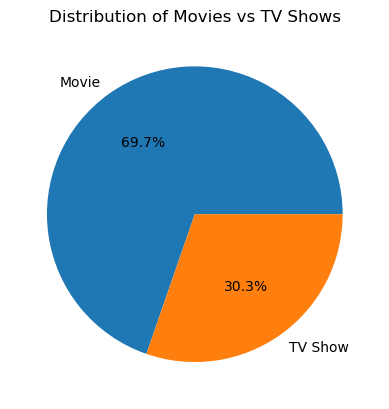

In [5]:
plt.figure()
df['type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Distribution of Movies vs TV Shows")
plt.ylabel('')
plt.show()

In [ ]:
To examine the year-wise growth of Netflix content to identify patterns and trends over time. 

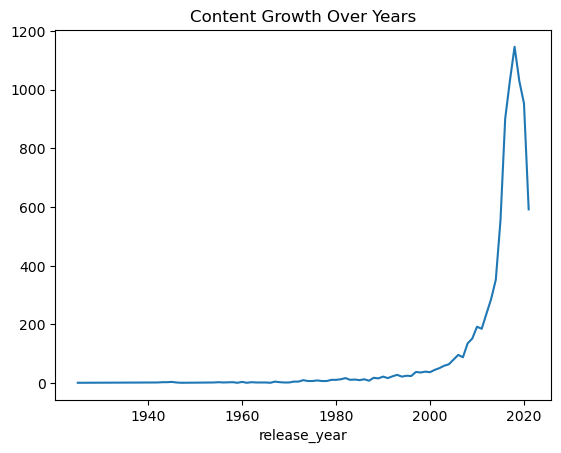

In [6]:
df['release_year'].value_counts().sort_index().plot()
plt.title("Content Growth Over Years")
plt.show()

In [ ]:
To identify the most popular genres and categories of content on the platform.

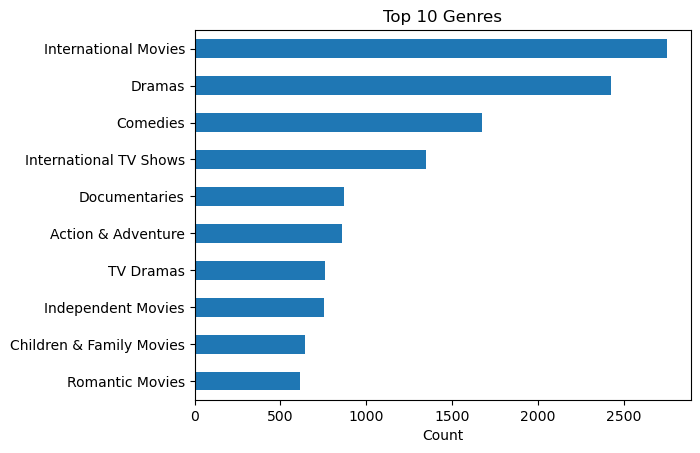

In [7]:
top_genres = df['listed_in'].str.split(', ', expand=True).stack().value_counts().head(10)

plt.figure()
top_genres.sort_values().plot(kind='barh')
plt.title("Top 10 Genres")
plt.xlabel("Count")
plt.show()

In [ ]:
To understand the growth pattern of Netflix content across different years. 

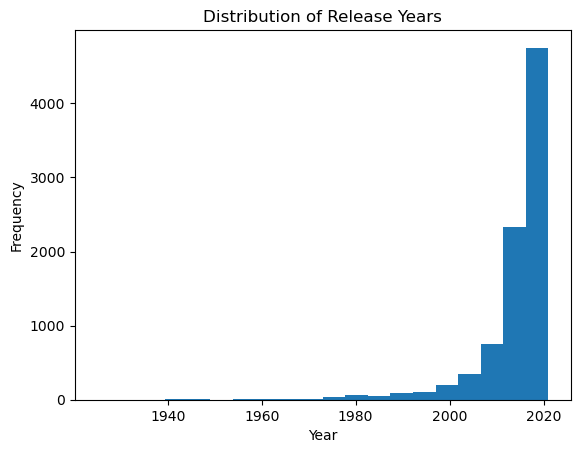

In [9]:
plt.figure()
df['release_year'].plot(kind='hist', bins=20)
plt.title("Distribution of Release Years")
plt.xlabel("Year")
plt.show()

In [10]:
top_years = df['release_year'].value_counts().head(10)
print(top_years)

release_year
2018    1146
2017    1030
2019    1030
2020     953
2016     901
2021     592
2015     555
2014     352
2013     286
2012     236
Name: count, dtype: int64


In [ ]:
To highlight the major content-producing countries and understand their contribution to Netflix’s library. 

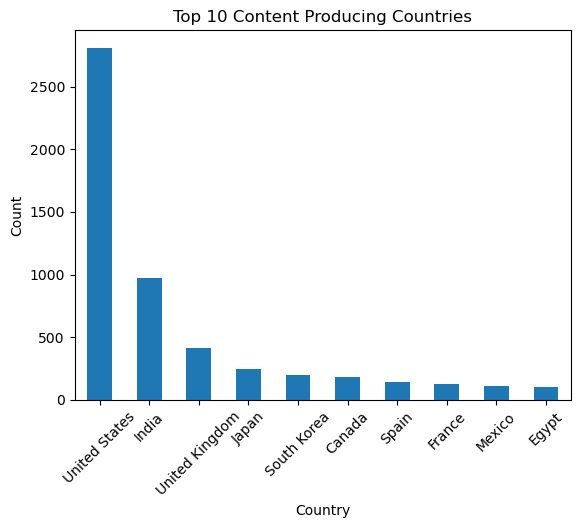

In [15]:
import matplotlib.pyplot as plt

plt.figure()
top_countries.plot(kind='bar')
plt.title("Top 10 Content Producing Countries")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [12]:
df = df[df['country'] != 'Unknown']
top_countries = df['country'].value_counts().head(10)
print(top_countries)

country
United States     2809
India              972
United Kingdom     418
Japan              243
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64


In [14]:
df.to_csv("cleaned_netflix_data.csv", index=False)
print(df.head())

  show_id     type                          title         director  \
0      s1    Movie           Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show                  Blood & Water          Unknown   
4      s5  TV Show                   Kota Factory          Unknown   
7      s8    Movie                        Sankofa     Haile Gerima   
8      s9  TV Show  The Great British Baking Show  Andy Devonshire   

                                                cast  \
0                                            Unknown   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...   
7  Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...   
8  Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...   

                                             country          date_added  \
0                                      United States  September 25, 2021   
1                                       South Africa  September 24, 2021   
4             